For discussion and details, please refer to:
https://www.kaggle.com/competitions/rogii-wellbore-geology-prediction/discussion/699853#3458633


## 1. Modeling
A simple CNN for multi-trajectory prediction using GR difference heatmap is constructed below

In [1]:
from typing import Tuple
import torch
from torch import Tensor, nn
import torch.nn.functional as F

class ConvBlock(nn.Module):
    def __init__(self, c_in: int, c_out: int, stride: Tuple[int, int] = (1, 1)):
        super().__init__()
        self.nt = nn.Sequential(
            nn.Conv2d(c_in, c_out, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(c_out),
            nn.GELU(),
        ) 
    def forward(self, x: Tensor) -> Tensor:
        return self.net(x)


class ConvBlock(nn.Module):
    def __init__(self, c_in: int, c_out: int, stride: Tuple[int, int] = (1, 1)):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(c_in, c_out, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(c_out),
            nn.GELU(),
        )
    def forward(self, x: Tensor) -> Tensor:
        return self.net(x)


class GeoStirringNet(nn.Module): 
    def __init__(self, K=10, L=24, cfg=None):
        super().__init__()
        self.cfg = cfg
        self.K = K # num path
        self.L = L # path length

        self.cnn = nn.Sequential(
            ConvBlock(2, 8),                 # [T,H]
            ConvBlock(8, 8),
            nn.AvgPool2d(kernel_size=(2, 2), stride=(2, 2)), #max pool
            ConvBlock( 8, 16),
            ConvBlock(16, 16),
            nn.AvgPool2d(kernel_size=(2, 2), stride=(2, 2)),
            ConvBlock(16, 32),
            ConvBlock(32, 32),
            nn.AvgPool2d(kernel_size=(2, 2), stride=(2, 2)),
            ConvBlock(32, 96),
            ConvBlock(96, 96),
        ) #todo: residual?

        self.head = nn.Sequential(
            nn.Linear(2304, 512, bias=False),#1536
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0),
            nn.Linear(512, 1024, bias=False),
            nn.BatchNorm1d(1024),
            nn.GELU(),
            nn.Linear(1024, 4096, bias=False),
            nn.BatchNorm1d(4096),
            nn.GELU(),
        )

        self.path_head = nn.Linear(4096, self.K*self.L)
        self.logit_head = nn.Linear(4096, self.K)

    def forward(self, heatmap, history):
        B,_1_,H,W = heatmap.shape

        x = self.cnn(torch.concat([heatmap, history], dim=1))
        flat = x.reshape(B,-1)
        h = self.head(flat)

        path  = self.path_head(h).view(B, self.K, self.L)
        logit = self.logit_head(h)

        # if tvt is limited with range:
        #     lo = float(self.cfg.path_min)
        #     hi = float(self.cfg.path_max)
        #     mid = 0.5 * (lo + hi)
        #     half = 0.5 * (hi - lo)
        #     paths = mid + half * torch.tanh(paths)

        return path, logit


def do_mtp_loss(pred, logit, target, alpha=1.0):
    """
    pred: [B, K, T]
    logit:     [B, K]
    target:    [B, T]
    """

    B, K, T = pred.shape 
    gt = target[:, None, :]

    # Per-mode trajectory error: [B, K]
    # Here using mean squared displacement error
    error = ((pred - gt) ** 2).mean(dim=-1)

    # Best matching trajectory for each sample: [B]
    best_k = error.argmin(dim=1)

    # Regression loss only for best trajectory
    reg_loss = error[torch.arange(B, device=pred.device), best_k].mean()

    # Classification loss: predict which mode is best
    cls_loss = F.cross_entropy(logit, best_k)

    return reg_loss + alpha * cls_loss

#########################################################################

def do_check_net():
    history = torch.rand(4, 1, 64, 24)
    heatmap = torch.rand(4, 1, 64, 24)
    truth = torch.rand(4, 24)
    
    net = GeoStirringNet()
    path, logit = net(history, heatmap)
    print(path.shape, logit.shape)

    loss = do_mtp_loss(path, logit, truth)
    print(loss)

do_check_net()
print('🌀 stirring network is ok!')

torch.Size([4, 10, 24]) torch.Size([4, 10])
tensor(2.6281, grad_fn=<AddBackward0>)
🌀 stirring network is ok!


## 2. Data preparation

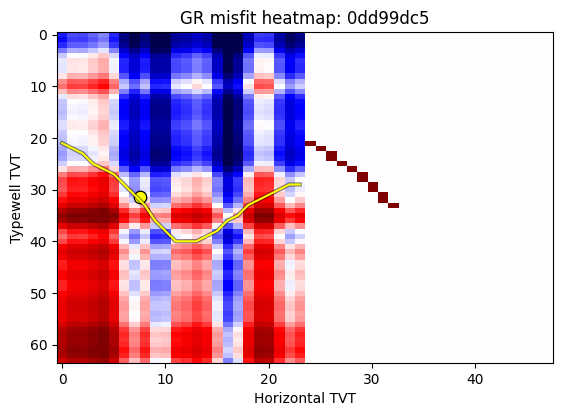

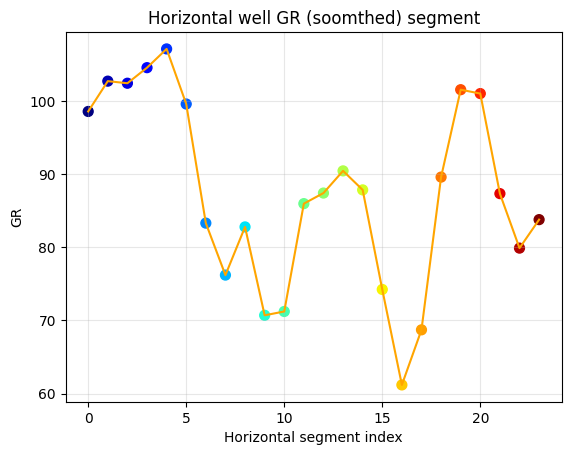

data check ok!!!


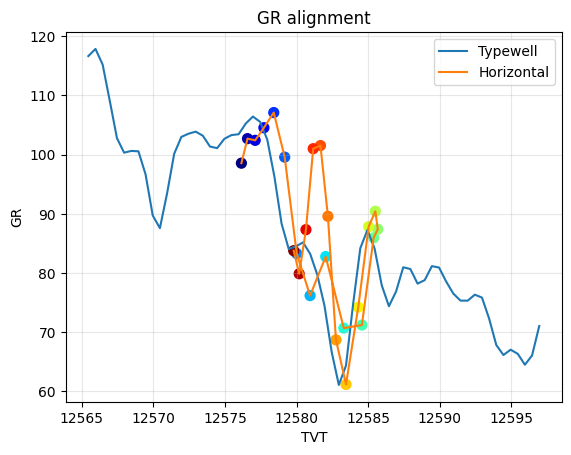

In [2]:
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter
import cv2

from matplotlib import pyplot as plt

KAGGLE_DIR = "/kaggle/input/competitions/rogii-wellbore-geology-prediction"

def load_one_sample(sample_id="000d7d20", offset=0):
    S = 32 #compression
    
    horizontal_csv = f"{KAGGLE_DIR}/train/{sample_id}__horizontal_well.csv"
    typewell_csv   = f"{KAGGLE_DIR}/train/{sample_id}__typewell.csv"
    h = pd.read_csv(horizontal_csv)
    t = pd.read_csv(typewell_csv)

    t_gr_filled = h["GR"].interpolate().bfill().ffill().values
    h_gr_smooth = savgol_filter(t_gr_filled, 100, 2)
    h_tvt = h["TVT"].values 
    t_tvt = t["TVT"].values
    t_gr  = t["GR"].values

    unknown = h[h["TVT_input"].isna().to_numpy()] #5821
    h_ps = int(np.flatnonzero(h["TVT_input"].notna().values)[-1]) + offset*S
    t_ps = np.abs(t_tvt-h_tvt[h_ps]).argmin()



    # cropping -------------------------------------- 
    L_unknown = len(h_tvt[h_ps:])
    L_unknown = int(L_unknown//S)

    i0 = h_ps-8*S
    i1 = h_ps+16*S#L_unknown*S
    h_seg_gr = h_gr_smooth[i0:i1].reshape(-1,S).mean(-1)
    h_seg_tvt = h_tvt[i0:i1].reshape(-1,S).mean(-1)
 
    j0 = t_ps-32
    j1 = t_ps+32 
    t_seg_gr  = t_gr[j0:j1]
    t_seg_tvt = t_tvt[j0:j1]
 
    # misfit heatmap
    heatmap =(h_seg_gr[None, :] - t_seg_gr[:, None])
    matched = np.abs(t_seg_tvt[:, None] - h_seg_tvt[None, :]).argmin(0)
    history = np.zeros((64,24)) 
    for i in range(8):
        cv2.line(history, (i,matched[i]), (i+1,matched[i+1]), 1, 1, cv2.LINE_AA)

    assert(heatmap.shape==(64,24)), sample_id  #hard code crop size for simplicity... modify this yourself!

    crop = (
        h_seg_gr, h_seg_tvt, t_seg_gr, t_seg_tvt
    ) 
    return heatmap, history, matched, crop


def do_check_data():
    sample_id="0dd99dc5"
    heatmap, history, matched, crop = load_one_sample(sample_id, offset=0)

    T,H = heatmap.shape
    h_seg_idx = np.arange(H)
    t_seg_idx = np.arange(T)    
    h_seg_gr, h_seg_tvt, t_seg_gr, t_seg_tvt = crop

    plt.imshow(
        np.hstack([heatmap, history*40]),
        vmax=40,
        vmin=-40, 
        cmap="seismic",
        aspect=0.5,      # smaller = flatter vertically
    )
    #fig.colorbar(im, ax=ax[0], label="GR difference")
 
    plt.title(f"GR misfit heatmap: {sample_id}")
    plt.xlabel("Horizontal TVT")
    plt.ylabel("Typewell TVT")

    plt.plot(h_seg_idx, matched, color="black", linewidth=3, alpha=0.5)
    plt.plot(h_seg_idx, matched, color="yellow")
    plt.scatter([8-0.5],[32-0.5],color="black", s=80, alpha=1) #PS point
    plt.scatter([8-0.5],[32-0.5],color="yellow", s=50, alpha=1)
    plt.show()
    
    #---
    plt.plot(h_seg_gr, color='orange')
    plt.scatter(h_seg_idx, h_seg_gr, c=h_seg_idx, cmap="jet", s=50)
    plt.title("Horizontal well GR (soomthed) segment")
    plt.xlabel("Horizontal segment index")
    plt.ylabel("GR")
    plt.grid(alpha=0.3)
    plt.show()

    #---
    plt.plot(t_seg_tvt, t_seg_gr, label="Typewell")
    plt.plot(h_seg_tvt, h_seg_gr, label="Horizontal")
    plt.scatter(h_seg_tvt, h_seg_gr, c=h_seg_idx, cmap="jet", s=50)
    plt.title("GR alignment")
    plt.xlabel("TVT")
    plt.ylabel("GR")
    plt.legend()
    plt.grid(alpha=0.3)

do_check_data()
print('data check ok!!!')

## 3. Run an inference model

<All keys matched successfully>
loss 7.605090141296387


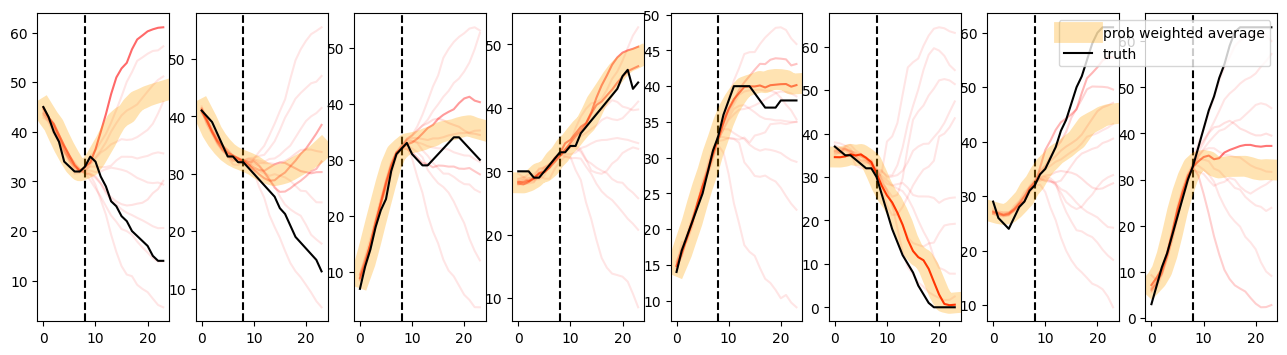

/tmp/ipykernel_16/3783929201.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


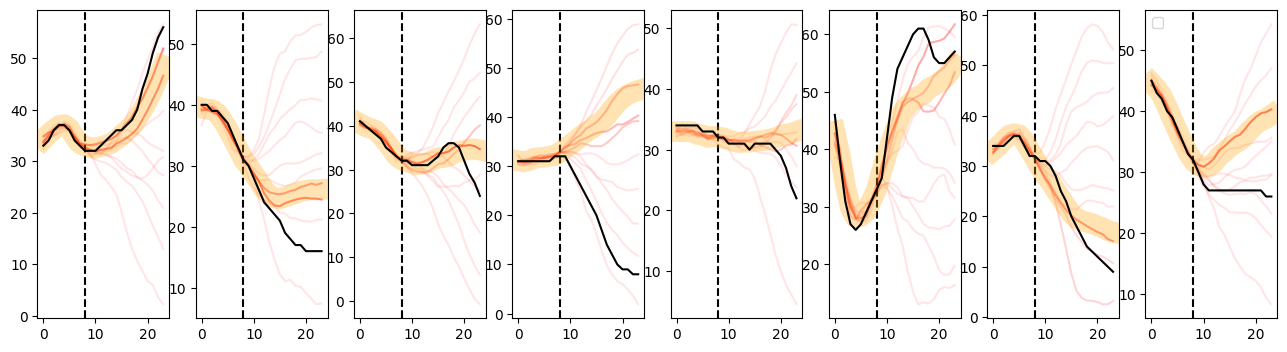

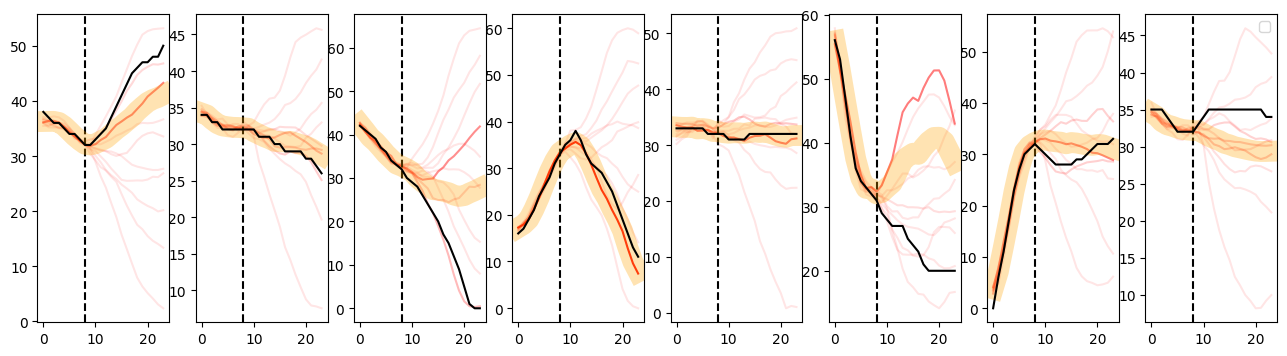

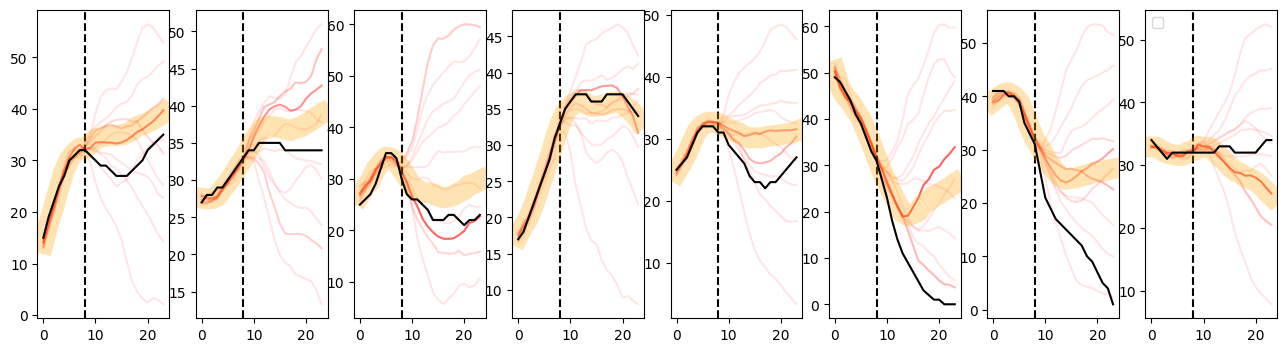

In [3]:
VALID_ID =['fcfcc902', '125be846', '1beca81d', '10a1281a', 'aff4e561', 'a5e6f7dc', 'd50c649a', '4a335117', 'a0b83014', '2d35f86d', '2d0c268a', 'c43812e2', '5fffa282', '63559d57', '2ee0235b', '96936c22', '8d5d46d7', '65156b96', '03a935ae', 'fbd68d27', '9c8375f7', 'b37fd114', 'b95e7121', 'c2c4db09', '89969c7a', '1770d7c6', '1619e2ca', 'c1708b88', 'ff8bb73a', '5397ceb1', '7850c72e', 'aee6393a', '99529c45', 'eba6605e', '7256229b', '283269ac', 'bb2cdd83', '33c40295', '24d8997e', 'e7818f7a', 'ddc790ff', '14fee784', 'a247e7cf', 'e0f36d98', 'be83e781', '367456ce', 'a0e92ed6', 'dc7f9757', '4f4ac5ce', '09ec2ca9', 'f0188a48', '3f603129', '77e4821c', '39b51819', '3417285d', '08fecf00', '9b5b61c1', 'f2d4c8c9', '14ab73fb', 'c9578d27', '865033f8', 'f88ddb26', '09053135', '1131525f', '5aef5c6c', '653612bc', '4b462989', 'abf460d2', 'ed6e6e54', 'a783cc24', 'a3518960', '729665c0', 'fc03f21f', 'be35c8f2', '46a7190b', 'dd168de0', '0e5e560d', '42c538a1', 'f6824bb0', '19137a89', '155887bb', '8bfa881d', '8b12bab6', '12f0cd90', '5aa03df7', 'd00e7eb9', 'da3cf798', '95b559e7', '9bd2bba3', '5f4d2a52', '5254b6db', '201661b5', 'cb879f40', '3a86fe8d', '44a94013', '1b6ba517', '7993a768', 'b04b58a3', '4630ab92', '204cc64b', '8255c867', '684a6fc1', '460f859e', 'ee0300f7', '5a5269a9', '8ac2f237', 'fa667be2', '521a7819', '727a3a10', 'fae0c593', 'fc0d20b2', 'e14d641e', '0a57a29c', 'c2717d4f', '97cd5bf9', 'dafc88c3', 'c6b782a4', 'da940160', 'd60430e6', 'c36625df', '62a6f539', 'f321a31c', 'eb934281', '481de5fc', '8612b37f', '373ef48b', '8a9c8932', '74b6186b', '6ede926a', '3b21ea64', 'b7cdcecb', '27300fd5', 'fb03ae90', 'cdc31d65', '177622d7', '16e4a047', '23b9beb0', '67847288', 'df71d1ff', 'c99f9fae', '2b547943', '726f3dc2', '543198e8', '81bf5923', 'e7d0c1de', '6d1d74e1', 'e45a2a62', '2cee0cba', 'e9949a23', 'a48640d9', '38991fd4', '3bfee975', '389ae58f', '153552f5', '310c71a5']

checkpoint ='/kaggle/input/datasets/hengck23/hengck23-rogii-cnn-mtp-demo/00036000.pth'

net = GeoStirringNet()
print(net.load_state_dict(torch.load(checkpoint, map_location=torch.device('cpu'))))
net.eval()

heatmap, history, matched = [],[],[]
b=0
while b<32:
    sample_id = VALID_ID[b] 
    he,hi,mp, _ = load_one_sample(sample_id,offset=0) #validate at PS    
    heatmap.append( he)
    history.append( hi)
    matched.append( mp)
    b +=1

heatmap = np.stack(heatmap)[:,None,:, :]
history = np.stack(history)[:,None,:, :]
matched = np.stack(matched)
heatmap = torch.from_numpy(heatmap).float()#.cuda()
history = torch.from_numpy(history).float()#.cuda()
truth = torch.from_numpy(matched).float()#.cuda()

with torch.no_grad():
    path, logit = net(history, heatmap)
    loss = do_mtp_loss(path, logit, truth)
    prob = F.softmax(logit, dim=1)


print("loss", loss.item())
prob = prob.data.cpu().numpy()
q = np.maximum(prob,0.1) #prob**0.5

path = path.data.cpu().numpy()
truth = truth.data.cpu().numpy()

for b in range(0,32,8):
    fig, ax = plt.subplots(1, 8, figsize=(16,4))
    for j in range(8):
        mean = (path[b+j]*prob[b+j][...,None]).sum(0)
        for k in range(10):
            ax[j%8].plot(path[b+j,k], color ="red", alpha=q[b+j,k])
        
        ax[j%8].axvline(8, color='black', linestyle='--')
        if b ==0:
            ax[j%8].plot(mean, color ="orange", linewidth=15, alpha=0.3, label='prob weighted average')
            ax[j%8].plot(truth[b+j], color ="black", alpha=1, label='truth')
        else:
            ax[j%8].plot(mean, color ="orange", linewidth=15, alpha=0.3)
            ax[j%8].plot(truth[b+j], color ="black", alpha=1)
    plt.legend()
    plt.show()
